In [1]:
import numpy as np
import pandas as pd


In [2]:
# Daten einlesen

df = pd.read_csv("ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# Features: Torque und Rotational Speed — standardisieren und Interaktion erstellen
# Wir verwenden die Originalspalten aus ai4i2020.csv: 'Torque [Nm]' und 'Rotational speed [rpm]'
try:
    df
except NameError:
    df = pd.read_csv("ai4i2020.csv")

cols = ['Torque [Nm]', 'Rotational speed [rpm]']
print('Prüfe Verfügbarkeit der Spalten:', [c for c in cols if c in df.columns])

# Standardisieren (z-score)
df['Torque_z'] = (df['Torque [Nm]'] - df['Torque [Nm]'].mean()) / df['Torque [Nm]'].std()
df['RotSpeed_z'] = (df['Rotational speed [rpm]'] - df['Rotational speed [rpm]'].mean()) / df['Rotational speed [rpm]'].std()

# Interaktionsterm
df['Torque_x_RotSpeed'] = df['Torque_z'] * df['RotSpeed_z']

df[['Torque [Nm]','Rotational speed [rpm]','Torque_z','RotSpeed_z','Torque_x_RotSpeed']].head()


Prüfe Verfügbarkeit der Spalten: ['Torque [Nm]', 'Rotational speed [rpm]']


,Torque [Nm],Rotational speed [rpm],Torque_z,RotSpeed_z,Torque_x_RotSpeed
0,42.8,1551,0.282186,0.068182,0.019240
1,46.3,1408,0.633276,-0.729435,-0.461934
2,49.4,1498,0.944242,-0.227438,-0.214757
3,39.5,1433,-0.048843,-0.589992,0.028817
4,40.0,1408,0.001313,-0.729435,-0.000958


In [22]:
# Designmatrix: Torque und Rotational Speed (beste Feature-Kombination)
# Beide bereits standardisiert als Torque_z und RotSpeed_z

# Anzahl Beobachtungen
n = df.shape[0]

# Designmatrix X: [1, Torque_z, RotSpeed_z]
X = np.column_stack([
    np.ones(n),
    df['Torque_z'].to_numpy(),
    df['RotSpeed_z'].to_numpy()
])

# Zielvektor y (PWF)
y = df['PWF'].to_numpy()

# Kontrolle: Shapes und erste Zeilen
print('X shape:', X.shape)
print('y shape:', y.shape)
X[:5]


X shape: (10000, 3)
y shape: (10000,)


array([[ 1.        ,  0.28218565,  0.06818173],
       [ 1.        ,  0.63327635, -0.72943503],
       [ 1.        ,  0.94424241, -0.22743847],
       [ 1.        , -0.04884274, -0.58999154],
       [ 1.        ,  0.00131308, -0.72943503]])

In [10]:
# Sigmoid- und Logloss-Funktion (Matrix-Formalismus, deutsch kommentiert)

# Sigmoid-Funktion: wählt Wahrscheinlichkeiten aus linearen Scores
def sigmoid(z):
    # numerisch stabil: clippen der Werte bevor exp gerechnet wird
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

# Logloss (negative log-likelihood) in Matrix-Form:
# L(theta) = - (1/n) * [ y^T log(p) + (1-y)^T log(1-p) ] mit p = sigmoid(X @ theta)
def logloss(theta, X, y, eps=1e-15):
    n = X.shape[0]
    z = X.dot(theta)            # linearer Score (n,)
    p = sigmoid(z)              # Wahrscheinlichkeiten (n,)
    # numerische Stabilität: eps vermeiden von log(0)
    p = np.clip(p, eps, 1 - eps)
    loss = - (1.0 / n) * (y.dot(np.log(p)) + (1 - y).dot(np.log(1 - p)))
    return loss

# Test mit Null-Parameter (Intercept=0, Koeffizienten=0)
theta0 = np.zeros(X.shape[1])
initial_loss = logloss(theta0, X, y)
print('Initialer Logloss (theta=0):', initial_loss)


Initialer Logloss (theta=0): 0.693147180559947


In [23]:
# Gradient Descent für logistische Regression (Matrix-Formalismus, deutsch kommentiert)

# Gradient der Logloss-Funktion (Matrixform)
def gradient(theta, X, y):
    n = X.shape[0]
    p = sigmoid(X.dot(theta))
    # Gradientenformel: (1/n) * X^T (p - y)
    return (1.0 / n) * X.T.dot(p - y)

# Einfacher Gradient Descent Optimierer
def gradient_descent(X, y, lr=0.5, max_iter=10000, tol=1e-7, verbose=True):
    theta = np.zeros(X.shape[1])
    losses = []
    for i in range(max_iter):
        g = gradient(theta, X, y)
        theta -= lr * g
        loss = logloss(theta, X, y)
        losses.append(loss)
        if verbose and (i % 1000 == 0):
            print(f'Iter {i}: loss={loss:.6f}')
        if np.linalg.norm(g) < tol:
            if verbose:
                print(f'Konvergenz bei Iteration {i}, ||grad||={np.linalg.norm(g):.3e}')
            break
    return theta, np.array(losses)

# Ausführen des GD mit Standardparametern
theta_gd, losses = gradient_descent(X, y, lr=0.5, max_iter=10000, tol=1e-7, verbose=True)
print('Finaler Logloss:', losses[-1])
print('Gefundene Theta-Koeffizienten:', theta_gd)


Iter 0: loss=0.580249
Iter 1000: loss=0.019464
Iter 2000: loss=0.015212
Iter 3000: loss=0.013577
Iter 4000: loss=0.012677
Iter 5000: loss=0.012096
Iter 6000: loss=0.011686
Iter 7000: loss=0.011379
Iter 8000: loss=0.011140
Iter 9000: loss=0.010949
Finaler Logloss: 0.010791613156530369
Gefundene Theta-Koeffizienten: [-9.48033964  5.58564503  4.41951298]


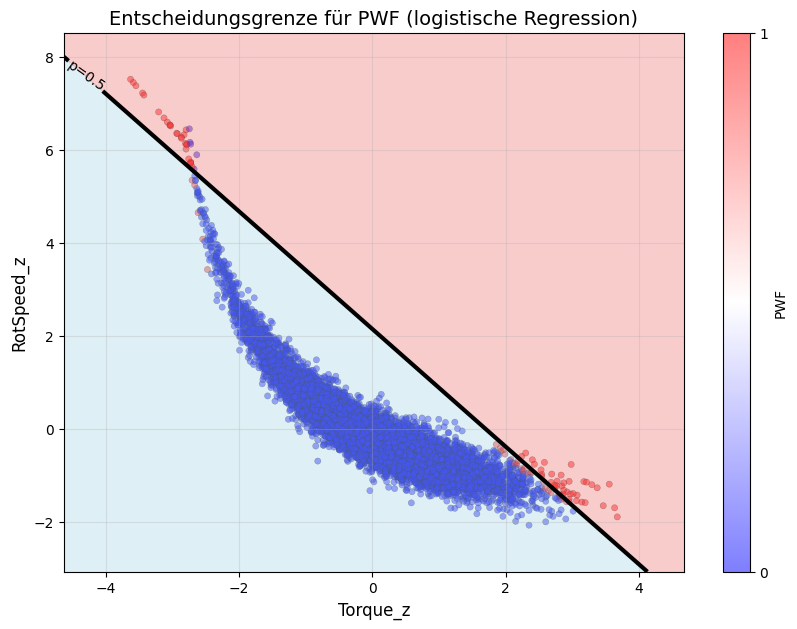

In [24]:
# Plot: Entscheidungsgrenze im Merkmalsraum (Torque_z vs RotSpeed_z)
import matplotlib.pyplot as plt

# Scatter der Datenpunkte (Farbe nach Zielvariable y)
plt.figure(figsize=(10, 7))
sc = plt.scatter(df['Torque_z'], df['RotSpeed_z'], c=y, cmap='bwr', alpha=0.5, s=20, edgecolor='k', linewidth=0.3)

# Entscheidungsgrenze: p = 0.5 <=> X @ theta = 0
theta = theta_gd

# Gitter für Kontur
tx = np.linspace(df['Torque_z'].min() - 1, df['Torque_z'].max() + 1, 300)
rx = np.linspace(df['RotSpeed_z'].min() - 1, df['RotSpeed_z'].max() + 1, 300)
XX, YY = np.meshgrid(tx, rx)
Z = sigmoid(theta[0] + theta[1] * XX + theta[2] * YY)

# Gefüllte Kontur (Hintergrund) — zeigt Entscheidungsregionen
plt.contourf(XX, YY, Z, levels=[0, 0.5, 1], colors=['lightblue', 'lightcoral'], alpha=0.4)

# Kontur bei p=0.5 (Entscheidungsgrenze) — deutlich hervorgehoben
cont = plt.contour(XX, YY, Z, levels=[0.5], colors='black', linewidths=3)
plt.clabel(cont, inline=True, fontsize=10, fmt='p=0.5')

plt.xlabel('Torque_z', fontsize=12)
plt.ylabel('RotSpeed_z', fontsize=12)
plt.title('Entscheidungsgrenze für PWF (logistische Regression)', fontsize=14)
plt.colorbar(sc, ticks=[0, 1], label='PWF')
plt.grid(alpha=0.3)
plt.show()


In [21]:
# Feature-Pair Vergleich: Welche zwei Features sind optimal?
# Teste verschiedene Kombinationen und vergleiche Konvergenz + Koeffizienten

feature_pairs = [
    ('Torque_z', 'RotSpeed_z', 'Torque vs RotSpeed'),
    ('Power_z', 'ToolWear_z', 'Power vs ToolWear (aktuell)'),
    ('Power_z', 'RotSpeed_z', 'Power vs RotSpeed'),
    ('Torque_z', 'ToolWear_z', 'Torque vs ToolWear'),
]

results = []

for feat1, feat2, label in feature_pairs:
    # Designmatrix konstruieren
    X_test = np.column_stack([
        np.ones(n),
        df[feat1].to_numpy(),
        df[feat2].to_numpy()
    ])
    
    # Trainieren
    theta_test, losses_test = gradient_descent(X_test, y, lr=0.5, max_iter=10000, tol=1e-7, verbose=False)
    final_loss = losses_test[-1]
    
    # Speichern
    results.append({
        'Features': label,
        'theta_0': theta_test[0],
        'theta_1': theta_test[1],
        'theta_2': theta_test[2],
        'Final Loss': final_loss,
        'Gradient Norm': np.linalg.norm(gradient(theta_test, X_test, y))
    })
    
    print(f'\n{label}:')
    print(f'  Theta: [{theta_test[0]:.4f}, {theta_test[1]:.4f}, {theta_test[2]:.4f}]')
    print(f'  Loss: {final_loss:.6f}')
    print(f'  |Gradient|: {np.linalg.norm(gradient(theta_test, X_test, y)):.3e}')

# Zusammenfassung als Tabelle
results_df = pd.DataFrame(results)
print('\n' + '='*80)
print('VERGLEICH ALLER FEATURE-PAARE:')
print(results_df.to_string(index=False))



Torque vs RotSpeed:
  Theta: [-9.4803, 5.5856, 4.4195]
  Loss: 0.010792
  |Gradient|: 5.349e-04

Power vs ToolWear (aktuell):
  Theta: [-5.0614, 0.9148, -0.0933]
  Loss: 0.049690
  |Gradient|: 9.978e-08

Power vs RotSpeed:
  Theta: [-8.8975, 4.5303, 3.8093]
  Loss: 0.016354
  |Gradient|: 3.245e-04

Torque vs ToolWear:
  Theta: [-5.0221, 0.8741, -0.0944]
  Loss: 0.050117
  |Gradient|: 9.960e-08

VERGLEICH ALLER FEATURE-PAARE:
                   Features   theta_0  theta_1   theta_2  Final Loss  Gradient Norm
         Torque vs RotSpeed -9.480340 5.585645  4.419513    0.010792   5.348981e-04
Power vs ToolWear (aktuell) -5.061367 0.914848 -0.093324    0.049690   9.977591e-08
          Power vs RotSpeed -8.897549 4.530286  3.809317    0.016354   3.244991e-04
         Torque vs ToolWear -5.022110 0.874090 -0.094449    0.050117   9.960386e-08


In [25]:
# Confusion Matrix, Precision, Recall, F1 Score (mit aktuellem Threshold 0.5)

# Predictions auf Trainingsdaten
p_pred = sigmoid(X.dot(theta_gd))  # Wahrscheinlichkeiten
threshold = 0.5
y_pred = (p_pred >= threshold).astype(int)  # Klassifizierungen (0 oder 1)

# Confusion Matrix Komponenten
TP = np.sum((y_pred == 1) & (y == 1))  # True Positives
TN = np.sum((y_pred == 0) & (y == 0))  # True Negatives
FP = np.sum((y_pred == 1) & (y == 0))  # False Positives
FN = np.sum((y_pred == 0) & (y == 1))  # False Negatives

# Metriken berechnen
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Ausgabe
print(f'Aktueller Threshold: {threshold}')
print(f'\nConfusion Matrix:')
print(f'                Pred=0  Pred=1')
print(f'True=0 (No PWF):  {TN:5d}  {FP:5d}')
print(f'True=1 (PWF):     {FN:5d}  {TP:5d}')
print(f'\nMetriken:')
print(f'  Accuracy:  {accuracy:.4f} ({TP+TN} korrekt von {len(y)} gesamt)')
print(f'  Precision: {precision:.4f} (von {TP+FP} Positiv-Vorhersagen sind {TP} korrekt)')
print(f'  Recall:    {recall:.4f} (von {TP+FN} echten Positiven werden {TP} erkannt)')
print(f'  F1-Score:  {f1:.4f}')


Aktueller Threshold: 0.5

Confusion Matrix:
                Pred=0  Pred=1
True=0 (No PWF):   9900      5
True=1 (PWF):        30     65

Metriken:
  Accuracy:  0.9965 (9965 korrekt von 10000 gesamt)
  Precision: 0.9286 (von 70 Positiv-Vorhersagen sind 65 korrekt)
  Recall:    0.6842 (von 95 echten Positiven werden 65 erkannt)
  F1-Score:  0.7879


THRESHOLD VERGLEICH:
 Threshold  TP  FP  FN  Accuracy  Precision   Recall  F1-Score
       0.1  92  92   3    0.9905   0.500000 0.968421  0.659498
       0.2  92  36   3    0.9961   0.718750 0.968421  0.825112
       0.3  87  13   8    0.9979   0.870000 0.915789  0.892308
       0.4  74   6  21    0.9973   0.925000 0.778947  0.845714
       0.5  65   5  30    0.9965   0.928571 0.684211  0.787879
       0.6  57   4  38    0.9958   0.934426 0.600000  0.730769
       0.7  44   4  51    0.9945   0.916667 0.463158  0.615385

🎯 Beste Threshold nach F1-Score: 0.3 (F1=0.8923)


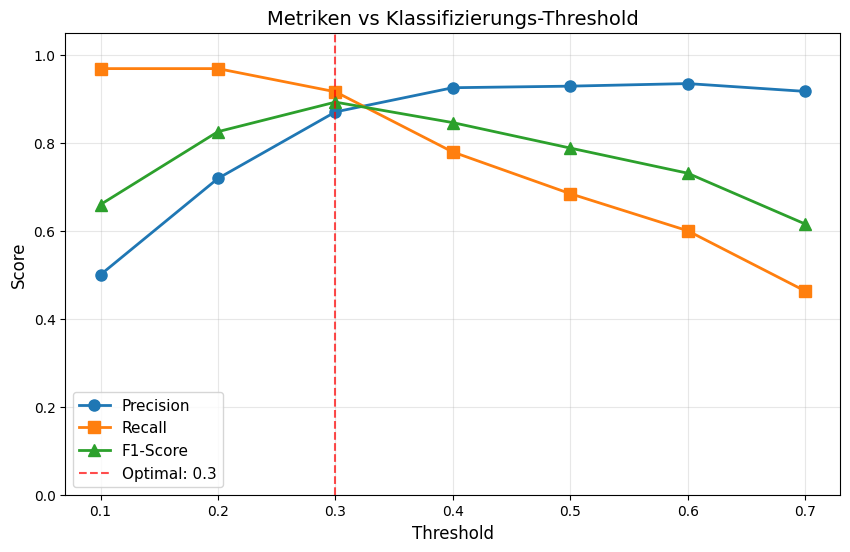

In [26]:
# Threshold Optimierung: Teste verschiedene Thresholds und vergleiche Metriken

thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
p_pred = sigmoid(X.dot(theta_gd))  # Wahrscheinlichkeiten (einmal berechnet)

threshold_results = []

for thresh in thresholds_to_test:
    y_pred = (p_pred >= thresh).astype(int)
    
    # Confusion Matrix
    TP = np.sum((y_pred == 1) & (y == 1))
    TN = np.sum((y_pred == 0) & (y == 0))
    FP = np.sum((y_pred == 1) & (y == 0))
    FN = np.sum((y_pred == 0) & (y == 1))
    
    # Metriken
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (TP + TN) / len(y)
    
    threshold_results.append({
        'Threshold': thresh,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Als Tabelle ausgeben
threshold_df = pd.DataFrame(threshold_results)
print('THRESHOLD VERGLEICH:')
print(threshold_df.to_string(index=False))

# Beste Threshold nach F1
best_idx = threshold_df['F1-Score'].idxmax()
best_thresh = threshold_df.loc[best_idx, 'Threshold']
print(f'\n🎯 Beste Threshold nach F1-Score: {best_thresh} (F1={threshold_df.loc[best_idx, "F1-Score"]:.4f})')

# Plot: Precision, Recall, F1 vs Threshold
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], 'o-', label='Precision', linewidth=2, markersize=8)
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], 's-', label='Recall', linewidth=2, markersize=8)
plt.plot(threshold_df['Threshold'], threshold_df['F1-Score'], '^-', label='F1-Score', linewidth=2, markersize=8)
plt.axvline(best_thresh, color='red', linestyle='--', alpha=0.7, label=f'Optimal: {best_thresh}')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Metriken vs Klassifizierungs-Threshold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.ylim([0, 1.05])
plt.show()
